# Machine Learning Foundations - Lab 4

## **Task 1: Linear Regression**

**Import libraries and load the dataset**



In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd

raw_df = pd.read_csv('data1.csv')


**Preview the raw dataset**

Use head() to inspect the structure before processing — the data is stored in an interleaved row format that requires reshaping before use.

In [4]:
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8


**Reshape the dataset into feature matrix X and target vector y**
- Independent variables span two consecutive rows per sample
- Even-indexed rows supply the first block of features; odd-indexed rows supply two more features
- The third column of every odd-indexed row is the target value y

In [5]:
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]


**Verify the reshaped feature vector for one sample**

In [6]:
print(X[1])

[2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
 7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
 9.1400e+00]


**Verify the corresponding target value for the same sample**

In [7]:
print(y[1])

21.6


**Split the dataset into training (60%) and test (40%) sets**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

**Confirm the shape of the training set**

In [9]:
print(X_train.shape)


(303, 13)


**Confirm the shape of the test set**

In [10]:
print(X_test.shape)

(203, 13)


**Instantiate and train the linear regression model**

In [11]:
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

**Print the regression coefficients**

Coefficients indicate the weight assigned to each feature in the linear model.

In [12]:
# regression coefficients
print('Coefficients: ', reg.coef_)


Coefficients:  [-8.95714048e-02  6.73132853e-02  5.04649248e-02  2.18579583e+00
 -1.72053975e+01  3.63606995e+00  2.05579939e-03 -1.36602886e+00
  2.89576718e-01 -1.22700072e-02 -8.34881849e-01  9.40360790e-03
 -5.04008320e-01]


**Print the variance score (R²)**

A score of 1.0 means perfect prediction; the closer to 1.0, the better the model explains variance in the test data.

In [13]:
# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg.score(X_test, y_test)))


Variance score: 0.720905667266174


**Generate predictions on the test set**

In [14]:
y_predict = reg.predict(X_test)

**Calculate and print the Mean Squared Error (MSE)**

MSE measures the average squared difference between predicted and actual values — lower is better.

In [15]:
mse = mean_squared_error(y_test, y_predict)
print(mse)

25.205774702366828


## **Task 2: Logistic Regression**

**Import libraries**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd

**Load the diabetes dataset with named columns**

In [17]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
df = pd.read_csv("diabetes.csv", header=None, names=col_names)


**Preview the loaded dataset**

In [18]:
df.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


**Define the feature columns to use as independent variables**

In [19]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

**Assign feature matrix X and target vector y**

In [20]:
X = df[feature_cols]
y = df.label

**Preview the feature matrix X**

In [21]:
X.head()

,pregnant,insulin,bmi,age,glucose,bp,pedigree
0,Pregnancies,Insulin,BMI,Age,Glucose,BloodPressure,DiabetesPedigreeFunction
1,6,0,33.6,50,148,72,0.627
2,1,0,26.6,31,85,66,0.351
3,8,0,23.3,32,183,64,0.672
4,1,94,28.1,21,89,66,0.167


**Preview the target vector y**

In [22]:
y.head()

,label
0,Outcome
1,1
2,0
3,1
4,0


**Drop the first row to align indexing between X and y**

In [23]:
X1 = X.iloc[1:]
y1 = y.iloc[1:]

**Confirm alignment of y1 after indexing adjustment**

In [24]:
y1.head()

,label
1,1
2,0
3,1
4,0
5,1


**Split the dataset into training (70%) and test (30%) sets**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.3, random_state=42)

**Confirm the shapes of the training and test sets**

In [26]:
print(X_train.shape, X_test.shape)

(537, 7) (231, 7)


**Import the LogisticRegression class**

In [27]:
# import the class
from sklearn.linear_model import LogisticRegression


**Instantiate and train the logistic regression model**
- max_iter=1000 ensures the solver has enough iterations to converge
- random_state=10 ensures reproducibility

In [28]:
logreg = LogisticRegression(random_state=10, max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=10)

**Generate predictions and compute the confusion matrix**
- The confusion matrix shows true positives, true negatives, false positives, and false negatives
- This gives a detailed breakdown of classification performance beyond just accuracy

In [29]:
# import the metrics class
from sklearn import metrics

# define the y_pred HERE
y_pred = logreg.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)


[[120  31]
 [ 30  50]]


**Visualize the confusion matrix as a heatmap**
- Color intensity reflects the count in each cell
- Axes are labeled with actual vs. predicted class labels for easy interpretation

Text(0.5, 427.9555555555555, 'Predicted label')

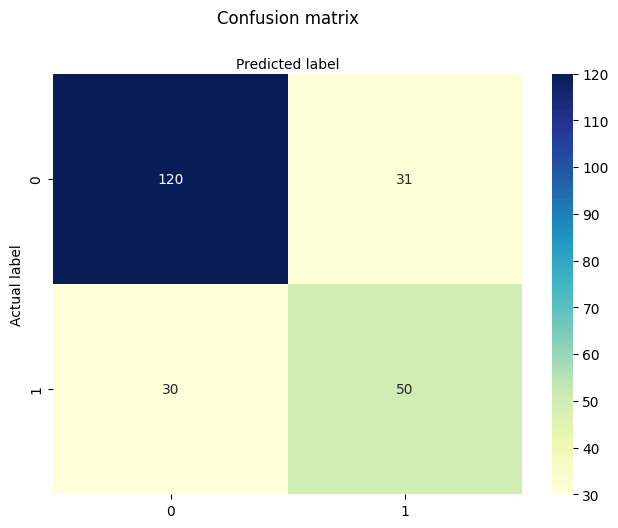

In [30]:

# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


**Print the classification report**
- Reports precision, recall, F1-score, and accuracy for each class
- Provides a richer view of performance than accuracy alone, especially for imbalanced datasets

In [31]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))


                  precision    recall  f1-score   support

without diabetes       0.80      0.79      0.80       151
   with diabetes       0.62      0.62      0.62        80

        accuracy                           0.74       231
       macro avg       0.71      0.71      0.71       231
    weighted avg       0.74      0.74      0.74       231



## **Task 3: Support Vector Machine**

## **Linear Kernel**

**Instantiate, train, and predict with a linear kernel SVM**
- SVC with a linear kernel finds the optimal separating hyperplane with maximum margin
- This serves as a baseline before trying the more complex RBF kernel

In [32]:
#Import svm model
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

**Compute the confusion matrix for the linear SVM**

In [33]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)


[[120  31]
 [ 30  50]]


**Visualize the confusion matrix for the linear SVM**

Text(0.5, 427.9555555555555, 'Predicted label')

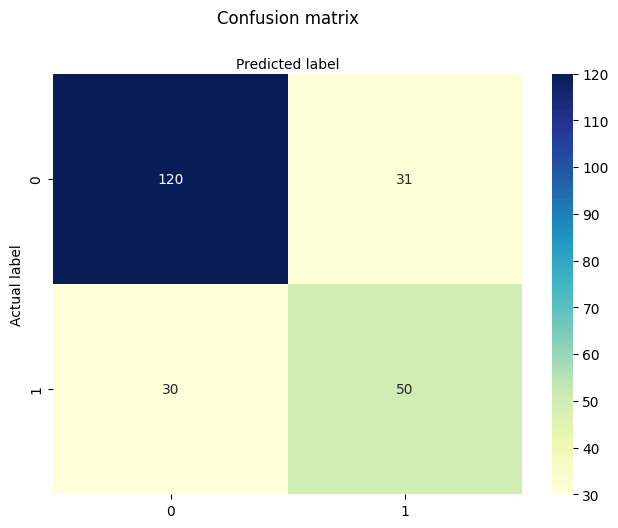

In [34]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

**Print the classification report for the linear SVM**

Compare these results with logistic regression to evaluate whether SVM offers any improvement.

In [35]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.80      0.79      0.80       151
   with diabetes       0.62      0.62      0.62        80

        accuracy                           0.74       231
       macro avg       0.71      0.71      0.71       231
    weighted avg       0.74      0.74      0.74       231



## **RBF Kernel — Grid Search (Accuracy Scoring)**

**Run Grid Search with cross-validation to find optimal C and gamma (optimizing accuracy)**
- C_range and gamma_range define the hyperparameter search space using logarithmic spacing
- StratifiedShuffleSplit preserves class proportions across each cross-validation fold
- GridSearchCV tests all (C, gamma) combinations and selects the pair with the best mean cross-validated accuracy

In [36]:
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC

C_range = np.logspace(0, 1, 5)
gamma_range = np.logspace(-9, 3, 10)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
grid.fit(X1, y1)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_))


The best parameters are {'C': np.float64(5.623413251903491), 'gamma': np.float64(1e-05)} with a score of 0.76


**Generate predictions using the best estimator and compute the confusion matrix**

In [37]:
y_pred = grid.predict(X_test)
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)

[[129  22]
 [ 36  44]]


**Visualize the confusion matrix for the best RBF model (accuracy-optimized)**

Text(0.5, 427.9555555555555, 'Predicted label')

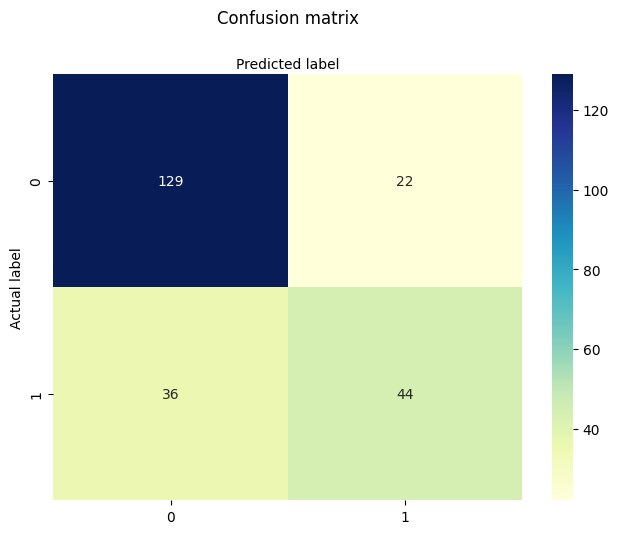

In [38]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

**Print the classification report for the best RBF model (accuracy-optimized)**

In [39]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.78      0.85      0.82       151
   with diabetes       0.67      0.55      0.60        80

        accuracy                           0.75       231
       macro avg       0.72      0.70      0.71       231
    weighted avg       0.74      0.75      0.74       231



## **RBF Kernel — Grid Search (Recall Scoring)**

**Re-run Grid Search optimizing for recall_macro instead of accuracy**
- recall_macro prioritizes minimizing false negatives, which is clinically important in disease detection
- A wider C_range and gamma_range are used to allow broader exploration of the hyperparameter space
- The best parameters here may differ from the accuracy-optimized search

In [40]:
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import SVC

C_range = np.logspace(0, 4, 10)
gamma_range = np.logspace(-9, 5, 10)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=42)
grid1 = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring ='recall_macro')
grid1.fit(X1, y1)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid1.best_params_, grid1.best_score_))

The best parameters are {'C': np.float64(59.94842503189409), 'gamma': np.float64(1.2915496650148827e-06)} with a score of 0.71
